In [10]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/House Price Prediction Dataset.csv')

# Display the number of rows and columns
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Display the data types of each feature
print("\nData types of each feature:")
display(df.info())

Number of rows: 2000
Number of columns: 10

Data types of each feature:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


None

In [11]:
# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Check for duplicate records
print(f"\nNumber of duplicate records: {df.duplicated().sum()}")


Missing values per column:
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

Number of duplicate records: 0


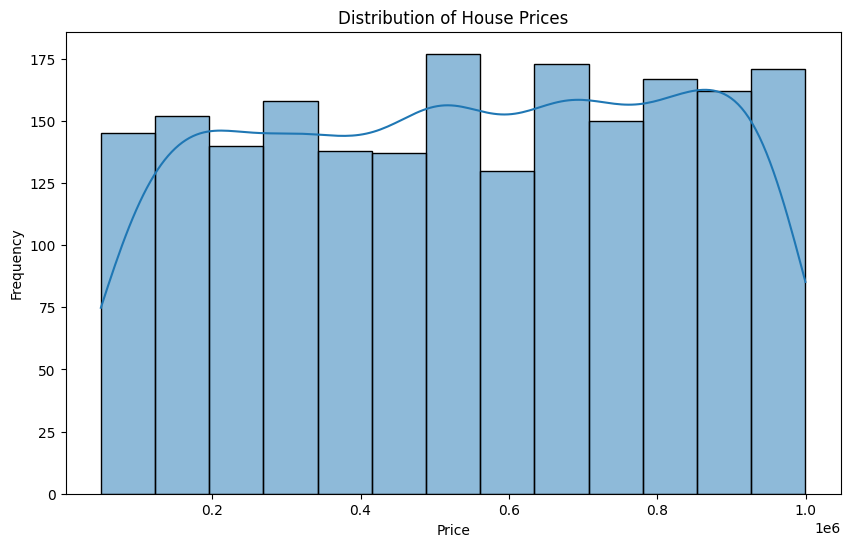

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of the target variable (Price)
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


Correlation of numerical features with Price:
Price        1.000000
Floors       0.055890
YearBuilt    0.004845
Area         0.001542
Bedrooms    -0.003471
Bathrooms   -0.015737
Name: Price, dtype: float64


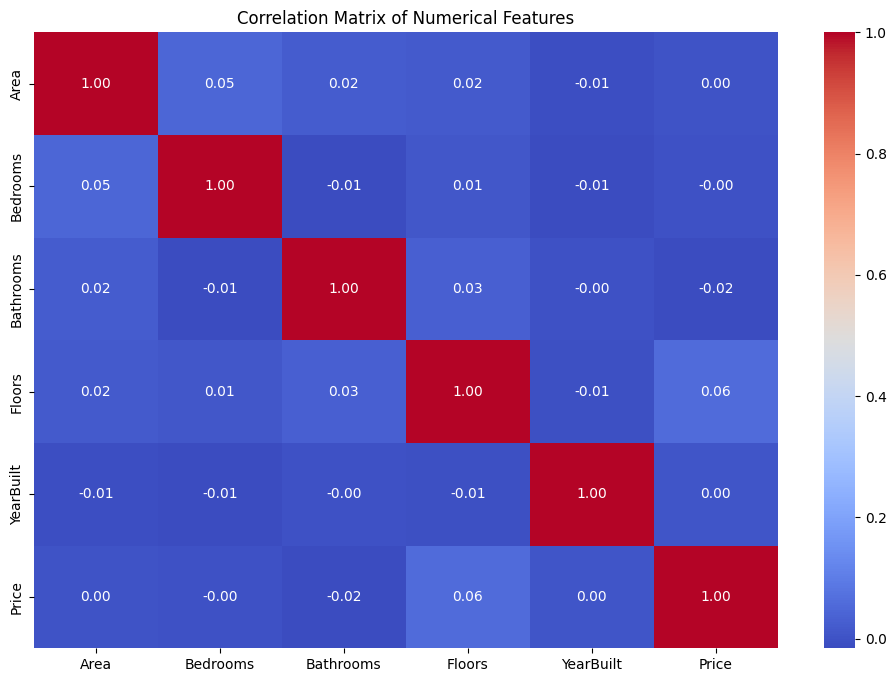

In [13]:
# Identify numerical features for correlation analysis (excluding 'Id')
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Id' in numerical_features:
    numerical_features.remove('Id')

# Calculate the correlation matrix
correlation_matrix = df[numerical_features].corr()

# Display the correlation with 'Price'
print("\nCorrelation of numerical features with Price:")
print(correlation_matrix['Price'].sort_values(ascending=False))

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()


Checking for outliers in numerical features using box plots:


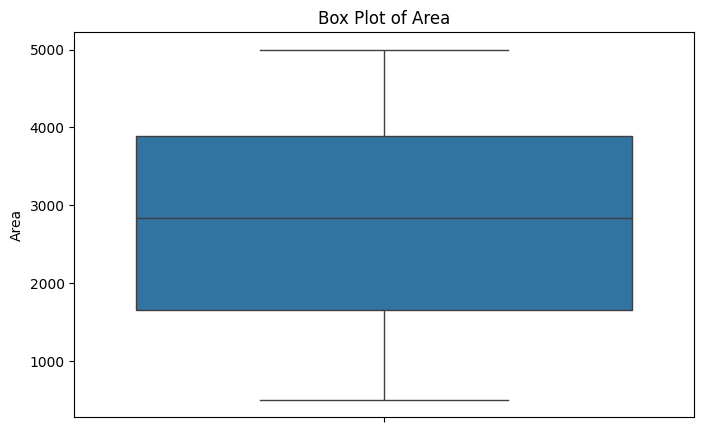

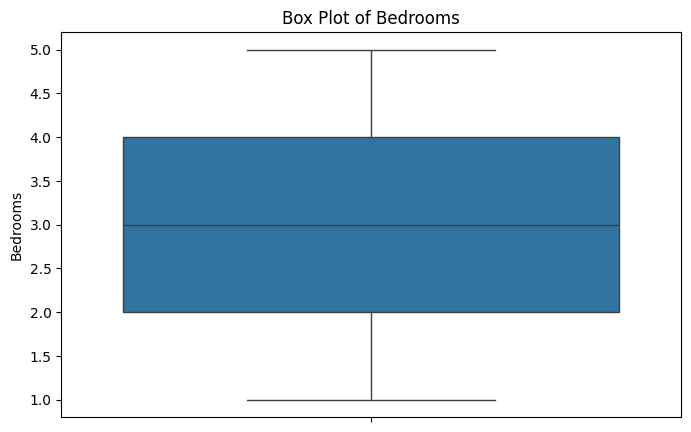

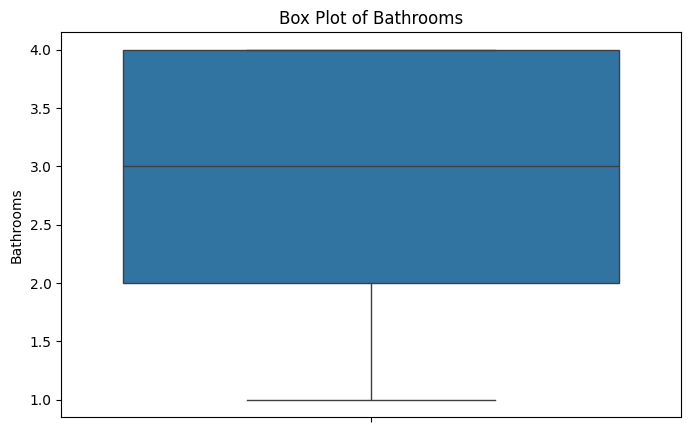

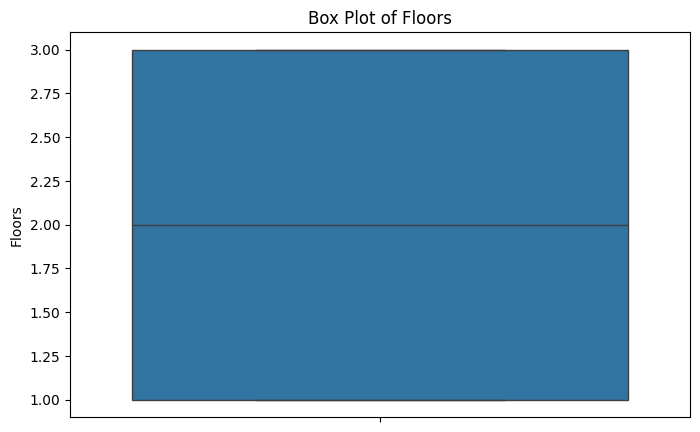

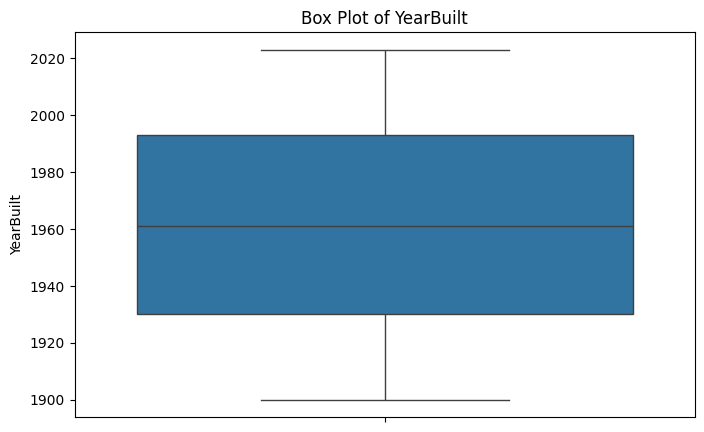

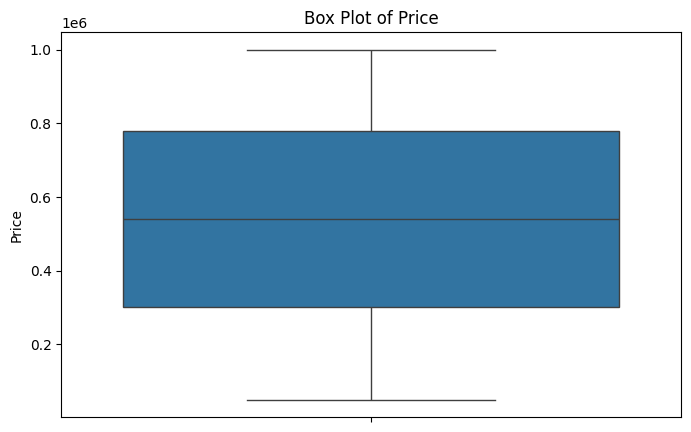

In [14]:
print("\nChecking for outliers in numerical features using box plots:")
for column in numerical_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=df[column])
    plt.title(f'Box Plot of {column}')
    plt.ylabel(column)
    plt.show()

In [15]:
# Identify categorical features
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# Apply one-hot encoding to categorical features
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

print("Original DataFrame head:")
display(df.head())
print("\nDataFrame after one-hot encoding head:")
display(df_encoded.head())
print(f"\nShape after encoding: {df_encoded.shape}")

Original DataFrame head:


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056



DataFrame after one-hot encoding head:


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1,1360,5,4,3,1970,149919,False,False,False,False,False,False,False
1,2,4272,5,4,3,1958,424998,False,False,False,False,False,False,False
2,3,3592,2,2,3,1938,266746,False,False,False,False,True,False,False
3,4,966,4,2,2,1902,244020,False,True,False,True,False,False,True
4,5,4926,1,4,2,1975,636056,False,False,False,True,False,False,True



Shape after encoding: (2000, 14)


In [16]:
from sklearn.model_selection import train_test_split

# Separate independent variables (X) and dependent variable (y)
X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

# Drop the 'Id' column from X as it's not a predictive feature
X = X.drop('Id', axis=1)

# Split the dataset into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (1600, 12)
Shape of X_test: (400, 12)
Shape of y_train: (1600,)
Shape of y_test: (400,)


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = linear_model.predict(X_test)

# Evaluate the model
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("--- Linear Regression Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae_lr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.2f}")
print(f"R-squared (R²): {r2_lr:.2f}")

print("\n--- Explanation of Metrics ---")
print("Mean Absolute Error (MAE): Represents the average of the absolute differences between predicted and actual values. It gives an idea of the average magnitude of errors.")
print("Root Mean Squared Error (RMSE): Is the square root of the average of the squared differences between predicted and actual values. It penalizes larger errors more heavily than MAE and is sensitive to outliers.")
print("R-squared (R²): Indicates the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher R² value (closer to 1) indicates a better fit of the model to the data.")

--- Linear Regression Model Evaluation ---
Mean Absolute Error (MAE): 243241.98
Root Mean Squared Error (RMSE): 279859.73
R-squared (R²): -0.01

--- Explanation of Metrics ---
Mean Absolute Error (MAE): Represents the average of the absolute differences between predicted and actual values. It gives an idea of the average magnitude of errors.
Root Mean Squared Error (RMSE): Is the square root of the average of the squared differences between predicted and actual values. It penalizes larger errors more heavily than MAE and is sensitive to outliers.
R-squared (R²): Indicates the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher R² value (closer to 1) indicates a better fit of the model to the data.


In [18]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the Decision Tree Regressor model
decision_tree_model = DecisionTreeRegressor(random_state=42)
decision_tree_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = decision_tree_model.predict(X_test)

# Evaluate the model
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("--- Decision Tree Regressor Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae_dt:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_dt:.2f}")
print(f"R-squared (R²): {r2_dt:.2f}")

print("\n--- Comparison with Linear Regression ---")
print(f"Linear Regression R²: {r2_lr:.2f}")
print(f"Decision Tree R²: {r2_dt:.2f}")

--- Decision Tree Regressor Model Evaluation ---
Mean Absolute Error (MAE): 328973.01
Root Mean Squared Error (RMSE): 401354.38
R-squared (R²): -1.07

--- Comparison with Linear Regression ---
Linear Regression R²: -0.01
Decision Tree R²: -1.07
